## Goal of this notebook 

(Following module 5 of https://ml-learn.mds.ubc.ca/en/)

- Identify when to implement feature transformations such as **imputation** and **scaling**.
- Apply `sklearn.pipeline.Pipeline` to build a machine learning **pipeline**.
- Use `sklearn` for applying numerical **feature transformations** on the data.
- Discuss the **golden rule** in the context of feature transformations.
- Carry out **hyperparameter optimization** using `RandomizedSearchCv`.

### Preprocessing

Preprocessing = Transforming input data into a format a machine learning model can use and
understand.

#### Basketball dataset

In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_validate
# from sklearn.datasets import fetch_california_housing
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

from sklearn.metrics import euclidean_distances, accuracy_score #or from sklearn.metrics.pairwise import euclidean_distances
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
all_stats = '../Data/kagglehub/datasets/jamiewelsh2/nba-player-salaries-2022-23-season/versions/2/nba_2022-23_all_stats_with_salary.csv'
salaries = '../Data/kagglehub/datasets/jamiewelsh2/nba-player-salaries-2022-23-season/versions/2/nba_salaries.csv'
bball_df = pd.read_csv(all_stats)
bball_df.head()

,Unnamed: 0,Player Name,Salary,Position,Age,Team,GP,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Total Minutes,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,0,Stephen Curry,48070014,PG,34,GSW,56,56,34.7,10.0,20.2,0.493,4.9,11.4,0.427,5.1,8.8,0.579,0.614,4.6,5.0,0.915,0.7,5.4,6.1,6.3,0.9,0.4,3.2,2.1,29.4,1941,24.1,0.656,0.564,0.248,2.3,16.8,9.7,30.0,1.3,0.9,12.5,31.0,5.8,2.0,7.8,0.192,7.5,0.1,7.5,4.7
1,1,John Wall,47345760,PG,32,LAC,34,3,22.2,4.1,9.9,0.408,1.0,3.2,0.303,3.1,6.7,0.459,0.457,2.3,3.3,0.681,0.4,2.3,2.7,5.2,0.8,0.4,2.4,1.7,11.4,755,13.6,0.498,0.322,0.334,2.1,11.4,6.8,35.3,1.8,1.4,17.1,27.0,-0.4,0.7,0.3,0.020,-0.8,-0.4,-1.2,0.1
2,2,Russell Westbrook,47080179,PG,34,LAL/LAC,73,24,29.1,5.9,13.6,0.436,1.2,3.9,0.311,4.7,9.7,0.487,0.481,2.8,4.3,0.656,1.2,4.6,5.8,7.5,1.0,0.5,3.5,2.2,15.9,2126,16.1,0.513,0.289,0.317,4.7,16.5,10.8,38.6,1.7,1.3,18.4,27.7,-0.6,2.6,1.9,0.044,0.3,-0.1,0.2,1.2
3,3,LeBron James,44474988,PF,38,LAL,55,54,35.5,11.1,22.2,0.500,2.2,6.9,0.321,8.9,15.3,0.580,0.549,4.6,5.9,0.768,1.2,7.1,8.3,6.8,0.9,0.6,3.2,1.6,28.9,1954,23.9,0.583,0.309,0.268,3.7,20.8,12.5,33.5,1.2,1.4,11.6,33.3,3.2,2.4,5.6,0.138,5.5,0.6,6.1,4.0
4,4,Kevin Durant,44119845,PF,34,BRK/PHO,47,47,35.6,10.3,18.3,0.560,2.0,4.9,0.404,8.3,13.4,0.617,0.614,6.5,7.1,0.919,0.4,6.3,6.7,5.0,0.7,1.4,3.3,2.1,29.1,1672,25.9,0.677,0.267,0.387,1.2,19.5,10.5,24.5,1.0,3.4,13.4,30.7,4.7,2.1,6.8,0.194,6.0,1.2,7.1,3.9


In [3]:
# salaries_df = pd.read_csv(salaries)
# salaries_df.head()

In [ ]:
X = bball_df[['AST', 'Age', 'Salary']]
y = bball_df['Position']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
X_train.head()

,AST,Age,Salary
382,1.4,23,1116112
22,1.4,26,35096500
305,1.4,21,2138160
46,3.0,36,26500000
153,1.2,21,7775400


In [7]:
dummy = DummyClassifier(strategy='most_frequent') # will simply predict most frequent category for all rows, no matter what x values are. This is not real machine learning but more a baseline prediction. A real machine learning algo is supposed to do much better than that. 

dummy.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [8]:
dummy.predict(X_test)

array(['SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG',
       'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG',
       'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG',
       'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG',
       'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG',
       'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG',
       'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG',
       'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG',
       'SG', 'SG', 'SG', 'SG', 'SG', 'SG'], dtype='<U2')

In [9]:
dummy.score(X_train, y_train)

0.24396782841823056

### Do cross validation

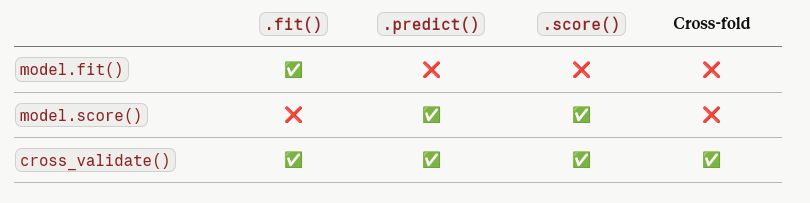

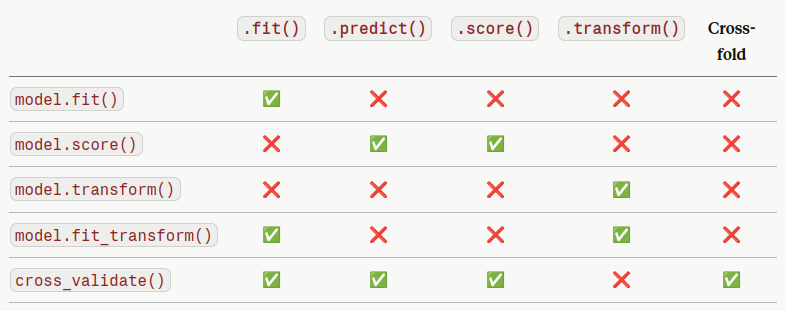

In [10]:
dummy = DummyClassifier(strategy='most_frequent')

In [11]:
scores = cross_validate(dummy, X_train, y_train, return_train_score=True, cv=2) # do cross validation using 2-folds
scores

/home/sbron/ProductivityStudy/venv_prod/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


{'fit_time': array([0.00192952, 0.00166702]),
 'score_time': array([0.00180387, 0.00142884]),
 'test_score': array([0.2459893 , 0.24193548]),
 'train_score': array([0.24193548, 0.2459893 ])}

In [12]:
print('mean validation test score:', scores['test_score'].mean())

mean validation test score: 0.24396239434190098


In [13]:
knn = KNeighborsClassifier()
scores = cross_validate(knn, X_train, y_train, return_train_score=True, cv=5) # do cross validation using 5-folds
scores

/home/sbron/ProductivityStudy/venv_prod/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


{'fit_time': array([0.0056622 , 0.00233054, 0.00193977, 0.00186062, 0.00183105]),
 'score_time': array([0.00555468, 0.00314236, 0.00244403, 0.00255013, 0.00252151]),
 'test_score': array([0.16      , 0.17333333, 0.2       , 0.16216216, 0.17567568]),
 'train_score': array([0.47651007, 0.45302013, 0.45973154, 0.46822742, 0.44816054])}

In [14]:
print('mean validation test score:', scores['test_score'].mean())

mean validation test score: 0.17423423423423426


In [15]:
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [16]:
knn.predict(X_test)

array(['PF', 'SG', 'C', 'SG', 'SG', 'SF', 'PF', 'PF', 'PG', 'PF', 'PF',
       'PF', 'SG', 'PF', 'SG', 'SF', 'C', 'C', 'C', 'PF', 'PF', 'SG', 'C',
       'SF', 'PF', 'SG', 'SG', 'SG', 'PG', 'SF', 'SF', 'PG', 'SF', 'C',
       'C', 'SF', 'PF', 'C', 'C', 'PF', 'PF', 'C', 'PG', 'C', 'C', 'PF',
       'PG', 'SG', 'SF', 'SF', 'PG', 'SF', 'C', 'C', 'PG', 'C', 'PF',
       'SG', 'SF', 'PG', 'PG', 'C', 'PG', 'SG', 'C', 'PF', 'SG', 'C',
       'SG', 'C', 'C', 'SF', 'PG', 'C', 'PG', 'SG', 'PF', 'C', 'SG', 'SF',
       'PG', 'SF', 'SF', 'C', 'SG', 'PG', 'PG', 'SF', 'SG', 'SG', 'SG',
       'SG', 'SG', 'C'], dtype=object)

We see that the dummy classifier (supposed to be the baseline, i.e. the worst) performs better than KNN. Why? 

In [17]:
two_players=X_train.sample(2, random_state=42)
two_players

,AST,Age,Salary
449,1.3,28,116986
116,1.4,25,10714287


The values in the `AST` columns are around 1 and in `Age` are 20. The values in `Salary` are much higher. 

In [18]:
euclidean_distances(two_players) # two_players = input matrix of shape n_samples_X = 2, n_features=3

array([[       0.        , 10597301.00000042],
       [10597301.00000042,        0.        ]])

In [19]:
euclidean_distances(two_players)[1,0]

np.float64(10597301.000000425)

In [20]:
two_players_subset = two_players[['Salary']]
two_players_subset

,Salary
449,116986
116,10714287


In [21]:
euclidean_distances(two_players_subset)[1,0]

np.float64(10597301.0)

The distance is completely dominated by the features with larger values. The features with smaller values are being ignored. This is not good: 
- Features on smaller scales can be highly informative. No reason to be ignored. 
- Want model to be robust and not sensitive to scale

To solve that, scale columns so that they all use similar range of values: `StandardScaler`

`StandardScaler` is called a _transformer_

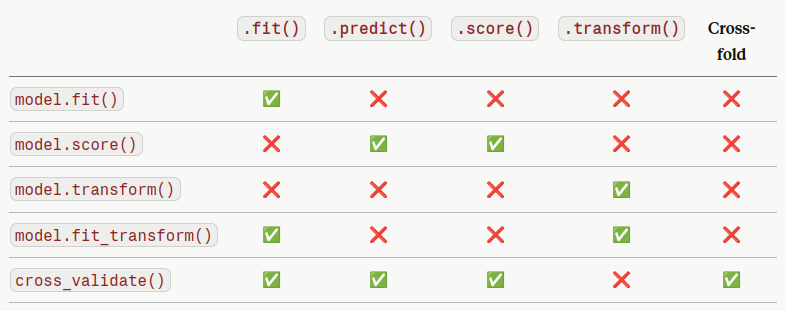

In [22]:
from sklearn.preprocessing import StandardScaler

Steps to do scaling: 
1. Create a feature transformer object. Done in a similar way as creating a model. Transformers accept hyperparameters as well. 
2. Fit transformer on train split
3. Transform the train split using `transform()`
4. Transfort the test split 

In [23]:
scaler = StandardScaler() #create feature transformer object 
scaler.fit(X_train) #fitting the transformer on the train split

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [24]:
X_train_scaled = scaler.transform(X_train)
X_train_scaled

array([[-0.35777447, -0.67086006, -0.6822708 ],
       [-0.35777447,  0.01345389,  2.56241676],
       [-0.35777447, -1.12706936, -0.58467844],
       ...,
       [ 0.02073004,  0.01345389, -0.61547139],
       [-0.89849521, -0.67086006, -0.76426946],
       [-0.46591862,  1.3820818 ,  0.38638034]], shape=(373, 3))

In [25]:
X_test_scaled = scaler.transform(X_test)

In [26]:
pd.DataFrame(X_train_scaled, columns=X_train.columns).head()

,AST,Age,Salary
0,-0.357774,-0.670860,-0.682271
1,-0.357774,0.013454,2.562417
2,-0.357774,-1.127069,-0.584678
3,0.507379,2.294500,1.741562
4,-0.465919,-1.127069,-0.046395


In [27]:
X_train.head()

,AST,Age,Salary
382,1.4,23,1116112
22,1.4,26,35096500
305,1.4,21,2138160
46,3.0,36,26500000
153,1.2,21,7775400


In [28]:
knn.fit(X_train, y_train)
X_train_prediction = knn.predict(X_train)

In [29]:
scaler.fit(X_train, [y_train])
X_train_transformed = scaler.transform(X_train)

# or X_train_transformed = scaler.fit_transform(X_tain) fitting and transforming in one call 

In [30]:
knn_unscaled = KNeighborsClassifier()
knn_unscaled.fit(X_train, y_train)

print('Train score', knn_unscaled.score(X_train, y_train))
print('Test score', knn_unscaled.score(X_test, y_test))


Train score 0.46648793565683644
Test score 0.20212765957446807


In [31]:
#Do scaling

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Do fitting
knn_scaled = KNeighborsClassifier()
knn_scaled.fit(X_train_scaled, y_train)

print('Train score', knn_scaled.score(X_train_scaled, y_train))
print('Test score', knn_scaled.score(X_test_scaled, y_test)) #does `score` also do the predict?

# #Do scaling and fitting in one step
# X_train_scaled = scaler.fit_transform(X_train)
# print('Train score', knn_scaled.score(X_train_scaled, y_train))


Train score 0.5040214477211796
Test score 0.20212765957446807


In [32]:
#Do scaling and fitting in one step
X_train_scaled = scaler.fit_transform(X_train)
print('Train score', knn_scaled.score(X_train_scaled, y_train))

Train score 0.5040214477211796


In [33]:
# --- SCALING ---
scaler = StandardScaler()
scaler.fit(X_train)                        # learns mean and std from train data
X_train_scaled = scaler.transform(X_train) # applies scaling to train
X_test_scaled = scaler.transform(X_test)   # applies same scaling to test

# --- FITTING THE MODEL ---
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)           # learns from scaled train data

# --- TRAIN SCORE ---
y_train_pred = knn.predict(X_train_scaled) # predicts on scaled train data
train_score = accuracy_score(y_train, y_train_pred)  # compares to true labels
print('Train score', train_score)

# --- TEST SCORE ---
y_test_pred = knn.predict(X_test_scaled)   # predicts on scaled test data
test_score = accuracy_score(y_test, y_test_pred)     # compares to true labels
print('Test score', test_score)

Train score 0.5040214477211796
Test score 0.20212765957446807


We can write the same thing in a concise version 

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform combined
X_test_scaled = scaler.transform(X_test) # only transform on test

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train) # fit on scaled data

knn.score(X_train_scaled, y_train)   # predict + accuracy_score combined
knn.score(X_test_scaled, y_test)     # predict + accuracy_score combined

print('Train score:', knn.score(X_train_scaled, y_train))
print('Test score:', knn.score(X_test_scaled, y_test))

Train score: 0.5040214477211796
Test score: 0.20212765957446807


Even more concise + avoid data leakage with pipeline.

```
pipe.fit(X_train, y_train):
  1. scaler.fit(X_train)
  2. X_train_scaled = scaler.transform(X_train)
  3. knn.fit(X_train_scaled, y_train)

pipe.score(X_test, y_test):
  1. X_test_scaled = scaler.transform(X_test)   ← uses stats from X_train, no leakage
  2. y_pred = knn.predict(X_test_scaled)
  3. accuracy_score(y_test, y_pred)
```

In [35]:
# --- BUILD PIPELINE ---
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# --- FIT ---
pipe.fit(X_train, y_train)         # internally: scaler.fit_transform(X_train) → knn.fit(X_train_scaled)

# --- SCORE ---
pipe.score(X_train, y_train)       # internally: scaler.transform(X_train) → knn.predict → accuracy_score
pipe.score(X_test, y_test)         # internally: scaler.transform(X_test) → knn.predict → accuracy_score

# print('Train score:', pipe.score(X_train_scaled, y_train))
# print('Test score:', pipe.score(X_test_scaled, y_test))


#with cross validate
results = cross_validate(pipe, X, y, return_train_score=True, cv=2)  # fit + scale + predict + score × 5 folds, no leakage
# print(results['test_score'].mean())
results

/home/sbron/ProductivityStudy/venv_prod/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


{'fit_time': array([0.00337434, 0.00314999]),
 'score_time': array([0.0029726 , 0.00290537]),
 'test_score': array([0.22222222, 0.25751073]),
 'train_score': array([0.51502146, 0.51282051])}

### Final compact form of everything for scaling example

In [37]:
# --- LOAD DATA ---
df = pd.read_csv('../Data/kagglehub/datasets/jamiewelsh2/nba-player-salaries-2022-23-season/versions/2/nba_2022-23_all_stats_with_salary.csv')

# --- DEFINE X AND y ---
X = df[['AST', 'Age', 'Salary']]   # features
y = df['Position']                 # target — the column you want to predict

# --- TRAIN/TEST SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- BUILD PIPELINE ---
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# --- FIT AND SCORE ---
pipe.fit(X_train, y_train)
# Less reliable — one lucky/unlucky split
print('Train score:', pipe.score(X_train, y_train))
print('Test score:', pipe.score(X_test, y_test))

# --- OPTIONAL: CROSS VALIDATION ---
# More reliable — averaged over 5 splits
results = cross_validate(pipe, X, y, cv=5)
print('CV scores - mean:', results['test_score'].mean())
print('CV scores: - std', results['test_score'].std())

Train score: 0.5040214477211796
Test score: 0.20212765957446807
CV scores - mean: 0.27185998627316404
CV scores: - std 0.03804103377971642


/home/sbron/ProductivityStudy/venv_prod/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


## Imputation


This is how to deal with missing data. For now, I should just remove all NaNs and I don't think this is gonna be useful for my work at this point, so skip it.

In [55]:
housing_df = pd.read_csv('../Data/kagglehub/datasets/harrywang/housing/versions/4/housing.csv')
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [56]:
train_df, test_df = train_test_split(housing_df, test_size=0.1, random_state=121)
train_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
4074,-118.43,34.14,44.0,1693.0,239.0,498.0,216.0,10.9237,500001.0,<1H OCEAN
8130,-118.18,33.80,15.0,2407.0,589.0,1591.0,506.0,3.0513,148100.0,NEAR OCEAN
11210,-117.92,33.82,10.0,1548.0,506.0,1535.0,424.0,4.5057,152400.0,<1H OCEAN
13898,-116.62,34.23,14.0,6438.0,1719.0,1586.0,691.0,1.6136,67400.0,INLAND
10188,-117.96,33.87,27.0,890.0,289.0,416.0,200.0,3.1410,167500.0,<1H OCEAN


Calculate variables that are useful for our prediction

In [57]:
train_df = train_df.assign(rooms_per_household=train_df['total_rooms']/train_df['households'], 
                           bedrooms_per_household=train_df['total_bedrooms']/train_df['households'],
                           population_per_household=train_df['population']/train_df['households'])


test_df = test_df.assign(rooms_per_household=test_df['total_rooms']/test_df['households'], 
                           bedrooms_per_household=test_df['total_bedrooms']/test_df['households'],
                           population_per_household=test_df['population']/test_df['households'])

train_df = train_df.drop(columns=['total_rooms', 'total_bedrooms', 'population'])
test_df = test_df.drop(columns=['total_rooms', 'total_bedrooms', 'population'])

train_df.head()

,longitude,latitude,housing_median_age,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_household,population_per_household
4074,-118.43,34.14,44.0,216.0,10.9237,500001.0,<1H OCEAN,7.837963,1.106481,2.305556
8130,-118.18,33.80,15.0,506.0,3.0513,148100.0,NEAR OCEAN,4.756917,1.164032,3.144269
11210,-117.92,33.82,10.0,424.0,4.5057,152400.0,<1H OCEAN,3.650943,1.193396,3.620283
13898,-116.62,34.23,14.0,691.0,1.6136,67400.0,INLAND,9.316932,2.487699,2.295224
10188,-117.96,33.87,27.0,200.0,3.1410,167500.0,<1H OCEAN,4.450000,1.445000,2.080000


In [59]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18576 entries, 4074 to 11586
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 18576 non-null  float64
 1   latitude                  18576 non-null  float64
 2   housing_median_age        18576 non-null  float64
 3   households                18576 non-null  float64
 4   median_income             18576 non-null  float64
 5   median_house_value        18576 non-null  float64
 6   ocean_proximity           18576 non-null  object 
 7   rooms_per_household       18576 non-null  float64
 8   bedrooms_per_household    18387 non-null  float64
 9   population_per_household  18576 non-null  float64
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
train_df.describe()

,longitude,latitude,housing_median_age,households,median_income,median_house_value,rooms_per_household,bedrooms_per_household,population_per_household
count,18576.000000,18576.000000,18576.000000,18576.000000,18576.000000,18576.000000,18576.000000,18387.000000,18576.000000
mean,-119.559326,35.624266,28.608904,498.952143,3.862688,206467.234981,5.431458,1.098289,3.082747
std,2.000498,2.134838,12.581171,378.496871,1.891618,115327.558519,2.531547,0.492448,10.940403
min,-124.300000,32.540000,1.000000,1.000000,0.499900,14999.000000,0.846154,0.333333,0.750000
25%,-121.780000,33.930000,18.000000,281.000000,2.559875,119300.000000,4.443644,1.006202,2.430380
50%,-118.490000,34.250000,29.000000,410.000000,3.531300,179200.000000,5.226924,1.049020,2.820594
75%,-118.000000,37.710000,37.000000,603.000000,4.738700,264600.000000,6.057889,1.100000,3.282977
max,-114.310000,41.950000,52.000000,6082.000000,15.000100,500001.000000,141.909091,34.066667,1243.333333


In [ ]:
#training data is missing 189 values for bedrooms_per_household
train_df['bedrooms_per_household'].isnull().sum()

np.int64(189)

In [62]:
X_train = train_df.drop(columns=['median_house_value', 'ocean_proximity'])
y_train = train_df['median_house_value']

X_test = test_df.drop(columns=['median_house_value', 'ocean_proximity'])
y_test = test_df['median_house_value']

In [66]:
#this shows the problem that the model has when trying to fit on missing data
knn = KNeighborsRegressor()
knn.fit(X_train, y_train)

ValueError: Input X contains NaN.
KNeighborsRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values